In [11]:
from dotenv import load_dotenv
import os

In [18]:
load_dotenv()
data_path = os.getenv("DATA_PATH")

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv(data_path)

df.replace("?", np.nan, inplace=True)

for col in ['workclass', 'occupation', 'native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)


In [15]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


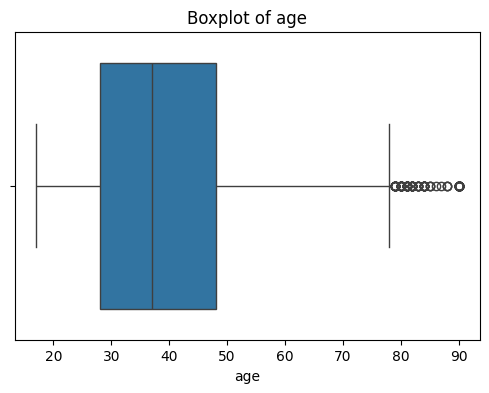

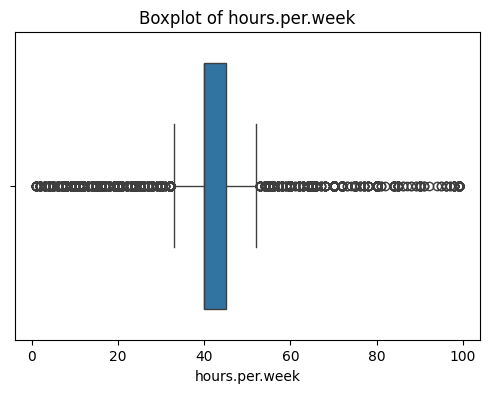

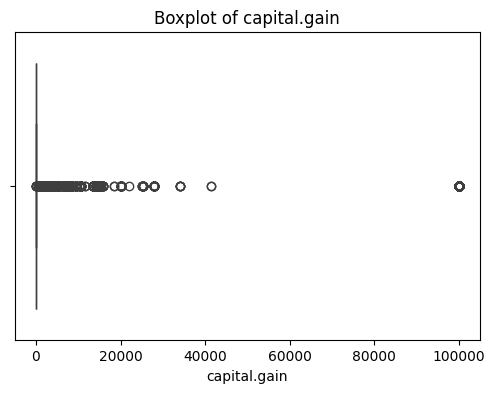

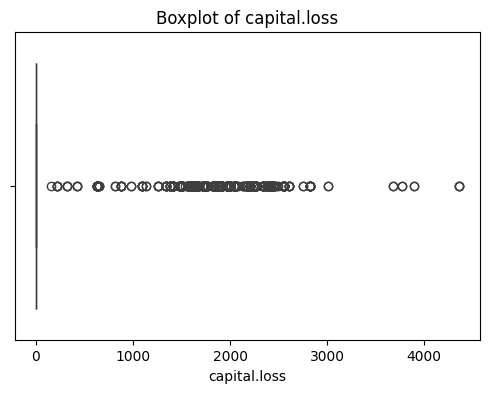

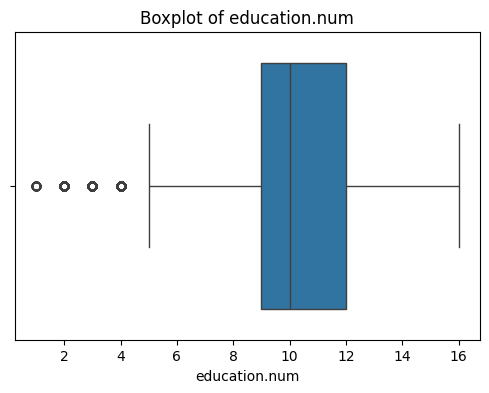

In [16]:
numerical_cols = ['age', 'hours.per.week', 'capital.gain', 
                  'capital.loss', 'education.num']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [20]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after IQR outlier removal:", df.shape)


Shape after IQR outlier removal: (19606, 15)


In [17]:
z_scores = np.abs(stats.zscore(df[numerical_cols]))

# Keep rows where all z-scores < 3
df_z = df[(z_scores < 3).all(axis=1)]

print("Shape after Z-score removal:", df_z.shape)


Shape after Z-score removal: (30131, 15)
